In [1]:
# basic tools
import os
os.environ["OMP_NUM_THREADS"] = "1" # Specificaly for small data set tto avoid memory leak

import numpy as np
import pandas as pd
import duckdb # Data base

#Visual tools
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
import plotly.express as px
import plotly.graph_objects as go

#Analysis tools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.stats as stats

In [2]:
# Connect to a database file 
con = duckdb.connect('../aav_manufacturing.db') 

## Calculating derived variables from raw data

In [3]:
query = """SELECT * FROM telemetry_aligned """
df_aligned = con.execute(query).df()

# Calculate instantaneous rates in the aligned dataframe
df_aligned = df_aligned.sort_values(['Batch_ID', 'Hour'])
df_aligned['dt'] = df_aligned.groupby('Batch_ID')['Hour'].diff()

# Growth Rate (mu): (ΔVCD / VCD) / Δt
df_aligned['Growth_Rate'] = df_aligned.groupby('Batch_ID')['VCD'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Production Rate (qp): ΔP / (VCD * Δt)
df_aligned['Production_Rate'] = df_aligned.groupby('Batch_ID')['Product'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Consumption Rate (qg): ΔG / (VCD * Δt)
df_aligned['Consumption_Rate'] = df_aligned.groupby('Batch_ID')['Glucose'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Register with DuckDB
con.register('telemetry_aligned', df_aligned)

## Agregating required data for analysis

In [4]:
query = """
SELECT 
    o.Batch_ID, 
    o.Status, 
    o.Full_Titer, 
    MAX(t.Ammonia) AS Max_Ammonia,
    MAX(t.Lactate) AS Max_Lactate,
    MIN(t.pH) AS Min_pH,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Growth_Rate END) AS Avg_Growth_Rate,
    AVG(CASE WHEN t.Hour >= 72 THEN t.Production_Rate END) AS Avg_Prod_Rate,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Consumption_Rate END) AS Avg_Gluc_Cons
FROM outcomes o
JOIN telemetry_aligned t ON o.Batch_ID = t.Batch_ID
GROUP BY o.Batch_ID, o.Status, o.Full_Titer
"""

df_pca_final = con.execute(query).df()
con.close()

## First PCA for relevant Principal Components

In [5]:
# Define features for the model
feature_cols = ['Max_Ammonia', 'Max_Lactate', 'Min_pH', 
                'Avg_Growth_Rate', 'Avg_Prod_Rate', 'Avg_Gluc_Cons']

# Handle missing values (if any rates couldn't be calculated)
df_pca_final = df_pca_final.dropna(subset=feature_cols)

# Scale the data (Mandatory for PCA)
scaler = StandardScaler()
X = scaler.fit_transform(df_pca_final[feature_cols])

In [6]:
# Run PCA
pca = PCA(n_components=5)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2','PC3','PC4','PC5'])
df_pca_plot['Status'] = df_pca_final['Status'].values

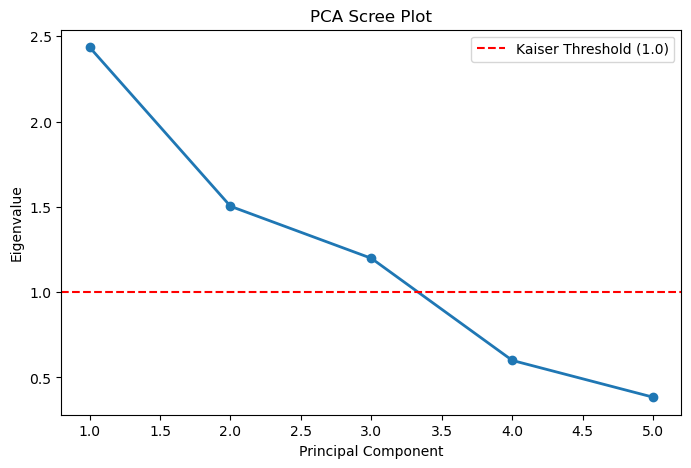

In [7]:
# Calculate Eigenvalues
eigenvalues = pca.explained_variance_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Threshold (1.0)')
plt.title('PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.show()

## Second PCA for visualization and clustering analysis

In [8]:
# Run PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
df_pca_plot['Status'] = df_pca_final['Status'].values

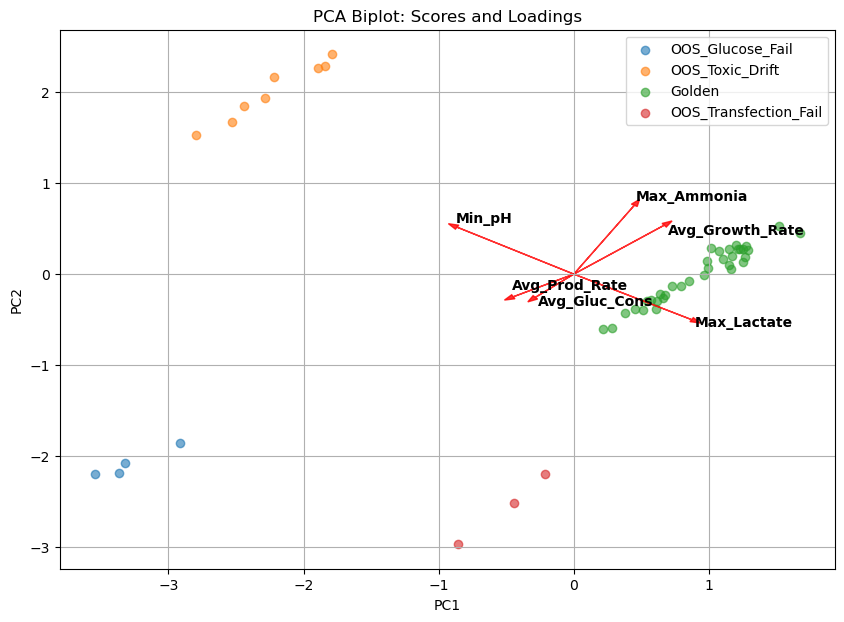

In [9]:
# Extract loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create Biplot
plt.figure(figsize=(10, 7))

# Plot the scores (the batches)
for status in df_pca_final['Status'].unique():
    mask = df_pca_final['Status'] == status
    plt.scatter(principal_components[mask, 0], principal_components[mask, 1], label=status, alpha=0.6)

texts = []
for i, feature in enumerate(feature_cols):
    texts.append(plt.text(loadings[i, 0], loadings[i, 1], feature, fontweight='bold'))
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.8, head_width=0.05)
# This function iteratively moves text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))


plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot: Scores and Loadings')
plt.legend()
plt.grid(True)
plt.show()

## Golden batch threshold

In [42]:
# 1. Fit PCA ONLY on Golden Batches to define the 'Normal' space
golden_mask = df_pca_final['Status'] == 'Golden'
p_components = 3
pca_golden = PCA(n_components=p_components)
scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_pca_final[golden_mask][feature_cols])
pca_golden.fit(train_scaled)

# 2. Project ALL batches (Golden + OOS) into this 'Golden Space'
all_scaled = scaler.transform(df_pca_final[feature_cols])
scores = pca_golden.transform(all_scaled)

eigenvalues = pca_golden.explained_variance_
t2_values = np.sum((scores**2) / eigenvalues, axis=1)

# 2. Calculate the 99% Confidence Threshold (UCL - Upper Control Limit)
# n: number of golden batches used for training
# p: number of PCs retained 
n = df_pca_final[golden_mask].shape[0]
p = p_components
alpha = 0.01
t2_threshold = (p * (n - 1) / (n - p)) * stats.f.ppf(1 - alpha, p, n - p)

# 3. Assign T2 to the dataframe for plotting
df_pca_final['T2_Statistic'] = t2_values
df_pca_final['OOS_Threshold'] = t2_threshold
df_pca_final['Alarm'] = df_pca_final['T2_Statistic'] > df_pca_final['OOS_Threshold']

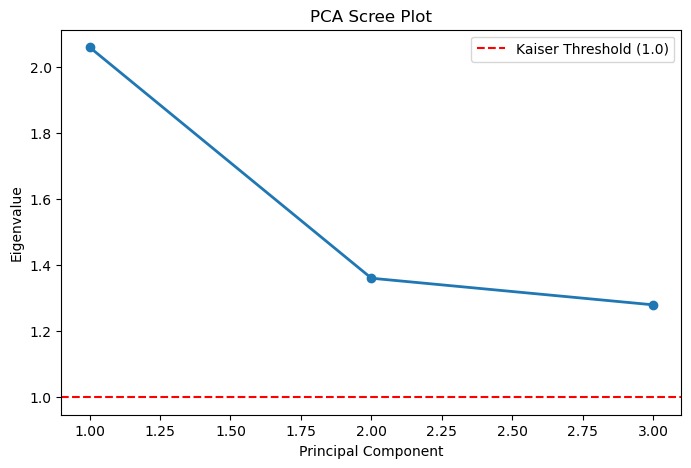

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Threshold (1.0)')
plt.title('PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.show()

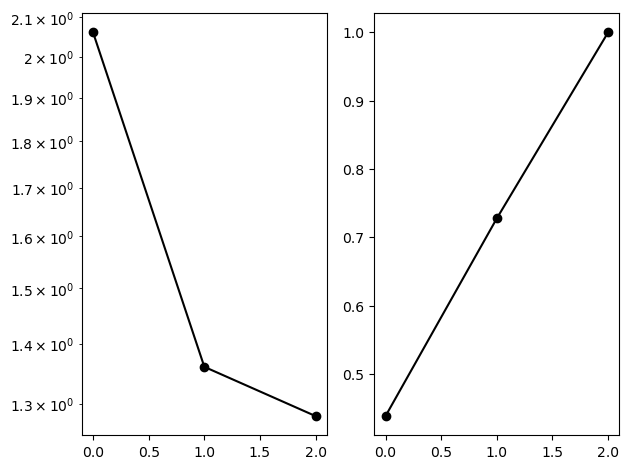

In [44]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(121)
ax1.semilogy(eigenvalues,'-o',color='k')
ax2 = fig1.add_subplot(122)
ax2.plot(np.cumsum(eigenvalues)/np.sum(eigenvalues),'-o',color='k')

plt.tight_layout()
plt.show()

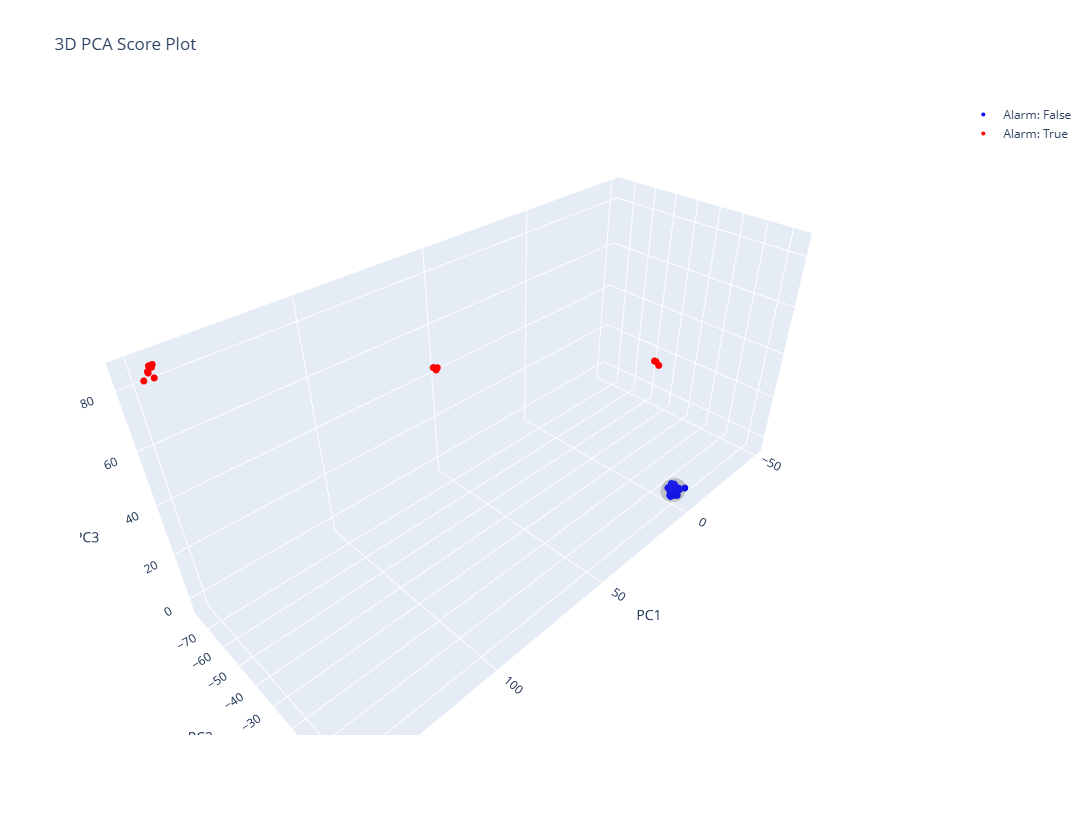

In [45]:
df_plot = pd.DataFrame(scores, columns=["PC1", "PC2", "PC3"])
df_plot['Alarm'] = df_pca_final['Alarm'].values
df_plot['Status'] = df_pca_final['Status'].values

eigenvalues = pca_golden.explained_variance_
radius_x = np.sqrt(t2_threshold * eigenvalues[0])
radius_y = np.sqrt(t2_threshold * eigenvalues[1])
radius_z = np.sqrt(t2_threshold * eigenvalues[2])

# 3. Create the Ellipse Shape
phi = np.linspace(0, np.pi, 50)
theta = np.linspace(0, 2 * np.pi, 50)
phi, theta = np.meshgrid(phi, theta)

x_ellipse = radius_x * np.sin(phi) * np.cos(theta)
y_ellipse = radius_y * np.sin(phi) * np.sin(theta)
z_ellipse = radius_z * np.cos(phi)


fig = go.Figure()

for alarm_val, color in zip([False, True], ['blue', 'red']):
    mask = df_plot['Alarm'] == alarm_val
    fig.add_trace(go.Scatter3d(
        x=df_plot.loc[mask, 'PC1'],
        y=df_plot.loc[mask, 'PC2'],
        z=df_plot.loc[mask, 'PC3'],
        mode='markers',
        marker=dict(size=4, color=color),
        name=f'Alarm: {alarm_val}'
    ))

fig.add_trace(go.Surface(
    x=x_ellipse, y=y_ellipse, z=z_ellipse,
    opacity=0.2,
    showscale=False,
    colorscale=[[0, 'gray'], [1, 'gray']],
    name='95% T2 Ellipsoid'
))

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title="3D PCA Score Plot with Hotelling T2 Ellipsoid"
)

fig.update_layout(
    width=1200,
    height=800,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title="3D PCA Score Plot"
)
fig.show()

In [48]:
# 1. Reconstruct the data from the PCA space
# This tries to 'guess' what the original values were based on the PCs
reconstructed = pca_golden.inverse_transform(scores)

# 2. Calculate the difference between actual scaled data and reconstruction
residuals = all_scaled - reconstructed
spe_values = np.sum(residuals**2, axis=1)

# 3. Calculate SPE threshold (Simplified Jackson-Mudholkar approximation)
# using the mean and variance of golden residuals:
spe_golden = spe_values[golden_mask]
mean_spe = np.mean(spe_golden)
var_spe = np.var(spe_golden)
g = var_spe / (2 * mean_spe)
h = (2 * mean_spe**2) / var_spe
spe_threshold = g * stats.chi2.ppf(1 - alpha, h)

df_pca_final['SPE_Statistic'] = spe_values
df_pca_final['SPE_Threshold'] = spe_threshold

In [51]:
h_spe_mask = df_pca_final["SPE_Statistic"] >6.707137
OOS_mask = df_pca_final["Status"] != "Golden"
alarm_mask = df_pca_final["Alarm"] == True
df_pca_final[OOS_mask]

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9     True
10    True
11    True
12    True
13    True
14    True
15    True
16    True
17    True
18    True
19    True
20    True
21    True
22    True
23    True
24    True
25    True
26    True
27    True
28    True
29    True
30    True
31    True
32    True
33    True
34    True
35    True
36    True
37    True
38    True
39    True
40    True
41    True
42    True
43    True
44    True
45    True
46    True
47    True
48    True
49    True
dtype: bool

## Hierarchical clustering

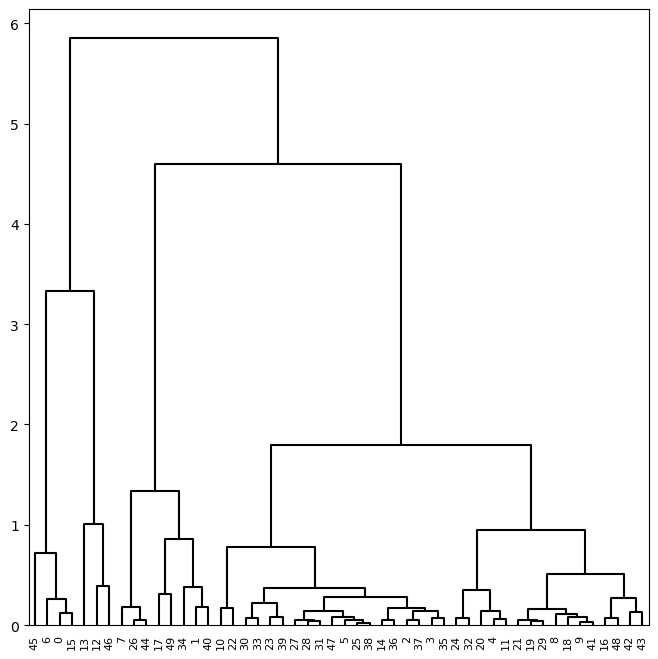

In [11]:
X = df_pca_plot[['PC1', 'PC2']].values
# 'complete' linkage matches your previous code
Z = linkage(X, method='complete')

# 3. Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# mimic your cargs: color_threshold=-np.inf makes the whole tree one color
dendrogram(
    Z, 
    ax=ax, 
    color_threshold=-np.inf, 
    above_threshold_color='black'
)

plt.show()

## K-means cluster

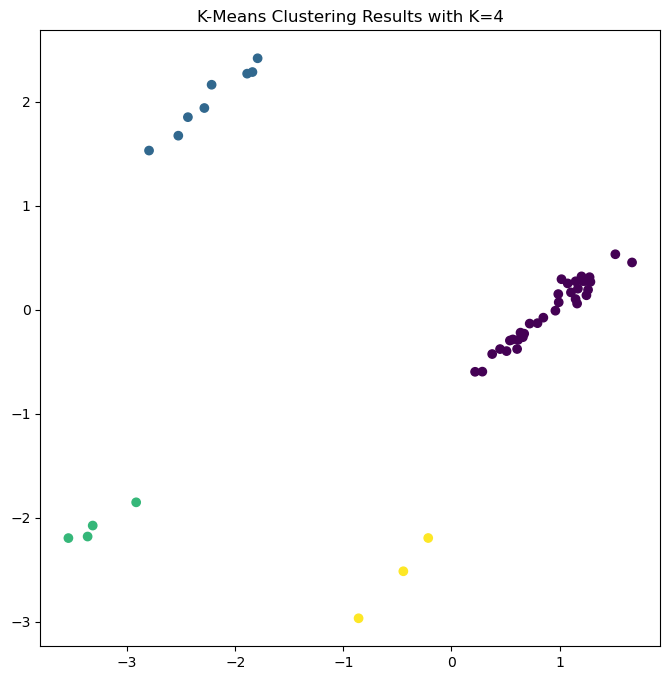

In [12]:
X = df_pca_plot[['PC1', 'PC2']].values
kmeans = KMeans(n_clusters=4, random_state=2, n_init=20).fit(X)

fig , ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=4");